<a href="https://colab.research.google.com/github/ridahafeez786/AI_Bootcamp_Lab-work/blob/main/VIT_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from torchvision import datasets, transforms

In [5]:
transformation= transforms.Compose([transforms.ToTensor()])

In [6]:
train_data=datasets.MNIST(root='./data',train=True, download=True, transform=transformation)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 409kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.1MB/s]


In [7]:
test_data=datasets.MNIST(root='./data',train=True, download=True, transform=transformation)

In [8]:
from torch.utils.data import DataLoader

In [9]:
train_dataloader= DataLoader(train_data, batch_size=32, shuffle=True, pin_memory=True )

In [10]:
test_dataloader= DataLoader(train_data, batch_size=32, shuffle=True, pin_memory=True )

In [11]:
image_batch, label_batch = next(iter(train_dataloader))

In [12]:
image_batch.shape

torch.Size([32, 1, 28, 28])

In [13]:
image=image_batch[0]
image.shape

torch.Size([1, 28, 28])

In [14]:
label=label_batch[0]
label

tensor(1)

In [15]:
import matplotlib.pyplot as plt

In [16]:
class_names=train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

Text(0.5, 1.0, '1 - one')

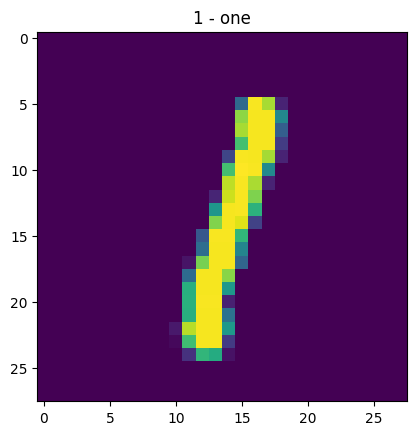

In [17]:
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])

In [3]:
import torch.nn as nn

In [18]:
num_channel=1
embedded_dim=16
patch_size=7
num_heads=8
mlp_nodes=64
image_size=28
num_classes=len(class_names)
batch_loss=0
patch_num=(image_size//patch_size) * (image_size//patch_size)

In [19]:
class patches(nn.Module):
  def __init__(self):
    super().__init__()
    self.embedded=nn.Conv2d(num_channel, embedded_dim, kernel_size=patch_size, stride=patch_size)
  def forward(self,x):
    x1=self.embedded(x)
    x2=x1.flatten(2)
    x3=x2.transpose(1,2)
    return x3
p=patches()
p

patches(
  (embedded): Conv2d(1, 16, kernel_size=(7, 7), stride=(7, 7))
)

In [27]:
class encoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_01=nn.LayerNorm(embedded_dim)
    self.multi_head=nn.MultiheadAttention(embedded_dim, num_heads=num_heads,batch_first=True)
    self.layer_02=nn.LayerNorm(embedded_dim)
    self.mlp=nn.Sequential(nn.Linear(embedded_dim, mlp_nodes),
                           nn.GELU(),
                           nn.Linear(mlp_nodes, embedded_dim))
  def forward(self,x):
    r_01=x
    x1=self.layer_01(x)
    x2=self.multi_head(x1,x1,x1)[0]
    x3=x2+r_01
    r_02=x3
    x4=self.layer_02(x3)
    x5=self.mlp(x4)
    x6=x5+r_02
    return x6

In [28]:
import torch

In [29]:
class transform_block(nn.Module):
  def __init__(self):
    super().__init__()
    self.patches=patches()
    self.cls_token= nn.Parameter(torch.randn(1,1,embedded_dim))
    self.positional_encoding=nn.Parameter(torch.randn(1,patch_num+1,embedded_dim))
    self.t_block = nn.Sequential(*[encoder() for _ in range(4)])
    self.mlp=mlp()
  def forward(self,x):
    x1=self.patches(x)
    batch=x1.shape[0]
    cls_token=self.cls_token.expand(batch,-1,-1)
    x2=torch.cat((cls_token,x1), dim=1)
    x3=self.positional_encoding+x2
    x4=self.t_block(x3)
    x4=x4[:,0]
    x5=self.mlp(x4)
    return x5

In [30]:
class mlp(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_01=nn.Sequential(nn.Linear(embedded_dim, num_classes))
  def forward(self,x):
    return self.layer_01(x)

In [31]:
vit=transform_block()

In [32]:
optimizer= torch.optim.Adam(vit.parameters(), lr=0.001)
loss_ftn=nn.CrossEntropyLoss()

In [37]:
# Initialize lists to store epoch-wise metrics
epoch_losses = []
epoch_accuracies = []

for epoch in range(5):
  # Reset metrics for the current epoch
  current_epoch_loss_sum = 0.0
  current_epoch_correct_samples = 0
  current_epoch_total_samples = 0

  for images, labels in train_dataloader:
    # Forward pass
    output = vit(images)
    loss = loss_ftn(output, labels)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Accumulate batch metrics
    current_epoch_loss_sum += loss.item()
    predictions = torch.argmax(output, dim=1) # Fix: specify dim=1 for argmax
    current_epoch_correct_samples += (predictions == labels).sum().item()
    current_epoch_total_samples += labels.shape[0]

  # Calculate epoch-average metrics
  avg_epoch_loss = current_epoch_loss_sum / len(train_dataloader)
  avg_epoch_accuracy = current_epoch_correct_samples / current_epoch_total_samples

  # Store epoch-average metrics
  epoch_losses.append(avg_epoch_loss)
  epoch_accuracies.append(avg_epoch_accuracy)

  print(f"Epoch {epoch+1}: Loss = {avg_epoch_loss:.4f}, Accuracy = {avg_epoch_accuracy:.4f}")

Epoch 1: Loss = 0.0613, Accuracy = 0.9799
Epoch 2: Loss = 0.0563, Accuracy = 0.9819
Epoch 3: Loss = 0.0546, Accuracy = 0.9813
Epoch 4: Loss = 0.0509, Accuracy = 0.9831
Epoch 5: Loss = 0.0480, Accuracy = 0.9839


Text(0.5, 1.0, 'Training loss curve')

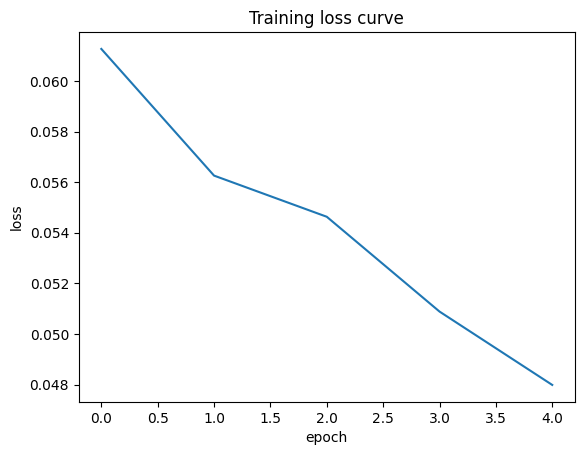

In [38]:
plt.plot(epoch_losses)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training loss curve")

Text(0.5, 1.0, 'Training acc curve')

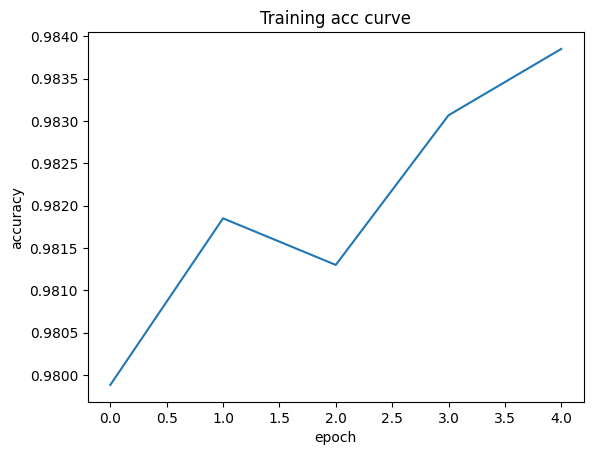

In [39]:
plt.plot(range(len(epoch_accuracies)), epoch_accuracies)
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Training acc curve")